# Neural Language Model

Bengio et. al

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [2]:
words =  open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
N = torch.zeros((27,27), dtype=torch.int32)

vocab = sorted(set(''.join(words))) # vocab
str_to_int = {s:i+1 for i,s in enumerate(vocab)}
str_to_int['.'] = 0

int_to_str = {i:s for s,i in str_to_int.items()}

str_to_int

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [4]:
# build dataset
# pad with dots to fit appropriate windw size of 3
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = str_to_int[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append to rolling window

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

In [5]:
C = torch.randn((27, 2)) # embed to 2-dim space
C[5]

tensor([0.3786, 0.2403])

In [6]:
# Alternatively left-multiply a one-hot vector into the row space of C
F.one_hot(torch.tensor(5), num_classes = 27).float() @ C

tensor([0.3786, 0.2403])

In [7]:
emb = C[Xtr]
emb.shape

torch.Size([182625, 3, 2])

In [8]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
h = emb.view(-1, 6) @ W1 + b1 # just view differently to get matmul to work!

In [9]:
print(h.shape)
print(b1.shape)

torch.Size([182625, 100])
torch.Size([100])


_Concat is less ideal here because this creates new memory/storage so is slower_

In [10]:
# these do the same thing...
print(torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape)
print(torch.cat(torch.unbind(emb, 1), 1).shape)

torch.Size([182625, 6])
torch.Size([182625, 6])


In [11]:
a = torch.arange(18)
print(a.view(9,2))
print(a.storage())# the underlying storage is still the same!


tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])
 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]


/var/folders/dv/3rt9dzq92qq4mwb8qz5mh_cw0000gn/T/ipykernel_15314/1772671507.py:3: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  print(a.storage())# the underlying storage is still the same!


In [12]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob[0].sum()

tensor(1.0000)

In [13]:
## or alternatively use cross entropy
loss = F.cross_entropy(logits, Ytr)
loss

tensor(42.3099)

In [14]:
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

In [15]:
losses = []
for _ in range(10000):
  # create minibatch
  ix = torch.randint(0, Xtr.shape[0], (32,))

  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  for p in parameters:
    p.grad = None

  loss.backward()
  for p in parameters:
    p.data += -.1 * p.grad
  losses += [loss.item()]
  #print(loss.item())

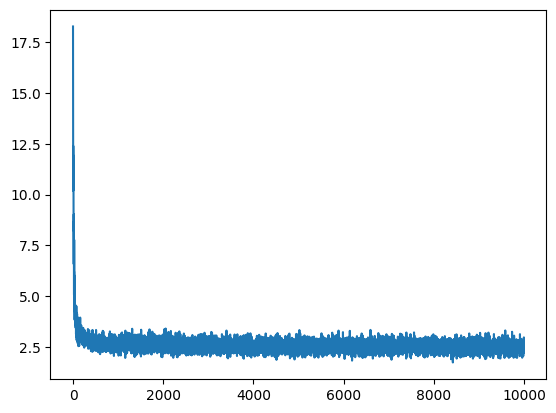

In [16]:
plt.plot(losses)

__In practice, better to make many steps with approximate gradient than few steps with an exact gradient__

In [17]:
emb = C[Xval]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss

tensor(2.4557, grad_fn=<NllLossBackward0>)

__Already lower than bigram loss!__

In [18]:
# Split to train/val/test

